In [1]:
import pylab as pl
import pandas as pd
import numpy as np
import scipy.stats
import os
import json
s = json.load( open(os.getenv ('PUI2015')+"/fbb_matplotlibrc.json") )
pl.rcParams.update(s)
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/Users/fbianco/Library/Enthought/Canopy_64bit/User/lib/python2.7/site-packages/matplotlib/__init__.py:855: UserWarning: svg.embed_char_paths is deprecated and replaced with svg.fonttype; please use the latter.
  warnings.warn(self.msg_depr % (key, alt_key))


#SUMMER (JUNE) RIDES

In [4]:
#reading in summer data: june, july, august, 3 months only, 
#because when i do the all-year data i will have 3 months, evenly spaced
#(since data for >semptember is not available yet for 2015)
df0 = pd.read_csv(os.getenv ('PUI2015')+'/201506-citibike-tripdata.csv')
df1 = pd.read_csv(os.getenv ('PUI2015')+'/201507-citibike-tripdata.csv')
df2 = pd.read_csv(os.getenv ('PUI2015')+'/201508-citibike-tripdata.csv')

dfsummer = pd.concat([df0,df1,df2])
dfsummer.age = 2015 - dfsummer['birth year'][(dfsummer['usertype']=='Subscriber')]
print dfsummer.age

0          31
1          18
2          22
3          34
5          39
6          39
7          53
8          42
9          57
10         51
11         33
12         30
13         26
14         32
15         39
16         30
17         60
18         38
19         31
20         44
21         22
22         25
23         43
24         29
26         26
27         32
28         26
29         29
30         48
31         38
           ..
1179005    33
1179009    31
1179010    29
1179011    52
1179014    44
1179015    24
1179016    39
1179018    36
1179019    24
1179021    25
1179022    31
1179023    45
1179024    52
1179025    48
1179026    25
1179027    35
1179028    44
1179029    34
1179030    42
1179031    22
1179032    28
1179033    42
1179034    41
1179035    31
1179037    22
1179038    26
1179039    27
1179040    45
1179041    33
1179043    40
Name: birth year, dtype: float64


#ALL YEAR RIDES

In [5]:
#reading in 3 month of citibike data from the local directory 
#(they are not all year because i am testing on 2015, but close enough: 
#i have winter, summer/spring and fall
#3 months to represent the year farily-ish
df3 = pd.read_csv(os.getenv ('PUI2015')+'/201501-citibike-tripdata.csv')
df4 = pd.read_csv(os.getenv ('PUI2015')+'/201504-citibike-tripdata.csv')
df5 = pd.read_csv(os.getenv ('PUI2015')+'/201508-citibike-tripdata.csv')

In [6]:
df = pd.concat([df3, df4, df5])
print df.columns

#df is the dataframe where the content of the csv file is stored
#throw away the non-subscribers, because data is incomplete for them
#print df['birth year']
print len(df)
df.age =  2015 - df['birth year'][(df['usertype']=='Subscriber')]

Index([u'tripduration', u'starttime', u'stoptime', u'start station id',
       u'start station name', u'start station latitude',
       u'start station longitude', u'end station id', u'end station name',
       u'end station latitude', u'end station longitude', u'bikeid',
       u'usertype', u'birth year', u'gender'],
      dtype='object')
2116986


            count_nonzero
birth year               
(0, 10]               NaN
(10, 20]         0.000133
(20, 30]        -0.007226
(30, 40]        -0.010467
(40, 50]        -0.005967
(50, 60]        -0.001825
(60, 70]        -0.000317
(70, 80]        -0.000007
(80, 90]         0.000000


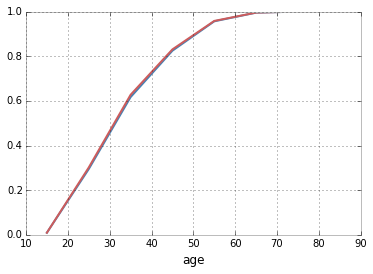

In [12]:
#print df.ageS, df.ageS.cumsum()

#bin size: for visualization use 10 days
bins = np.arange(0, 99, 10)

#this bins the data in 10 year bins (creates the histogram which i can treat like a PDF)
#cumsum takes the cumulative sum (which i can treat like a CDF if it normalize it properly)
cs1=df.age.groupby(pd.cut(df.age, bins)).agg([count_nonzero]).cumsum()

cs2=dfsummer.age.groupby(pd.cut(dfsummer.age, bins)).agg([count_nonzero]).cumsum()

#CDF by definition go from 0 to 1: 0 is the probability that 
#a value from the distribution be lower then that minimum value of the distributon
#which is 0 for any value P=0
#1 is the probability that a value from the distribution be lower then the maximum 
#value of the distribution (which is true by definition for any allowed value : P=1)
#so the normalization is just deviding the cumulative distribution by its max value
#NOTE: 5 is a half of the bin size: 
#i want to calculate the distribution at the center of the bin

pl.plot(bins[:-1]+5, cs1/cs1.max(), label="allyear")
pl.plot(bins[:-1]+5, cs2/cs2.max(), label="summer")
pl.xlabel("age")
#they are so similar i am gonna print the difference bin by bin to make sure i am not plotting the same thing twice...
print  cs1/cs1.max() -  cs2/cs2.max()

mean and standard deviation of the distribution: 
mean: 38.55 standard dev: 11.50
0.0346992059761 0.0210461322922 0.0341781467335


KeyboardInterrupt: 

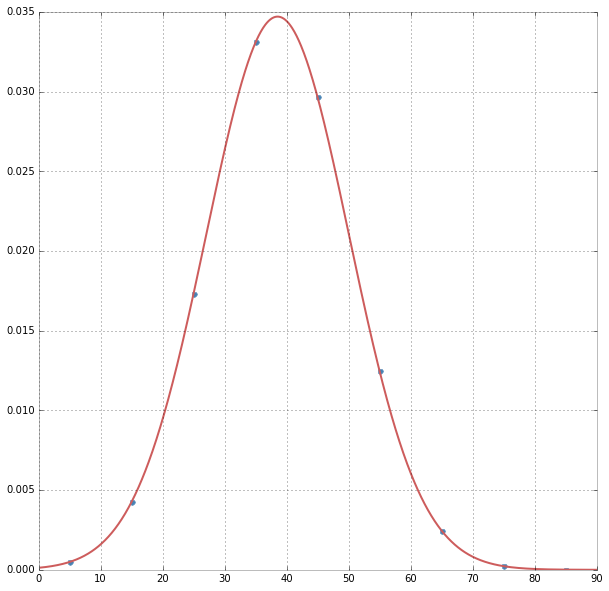

In [15]:
#same plot
bin_centers = bins[:-1] + (bins[1] - bins[0]) * 0.5

# i use nanmean and nanstd to get the mean and std avoiding NaN items

m = np.nanmean(df.age)
s = np.nanstd(df.age)

print 'mean and standard deviation of the distribution: '
print 'mean: {0:.2f} standard dev: {1:.2f}'.format(m, s)

def model(x, mean, sigma) : 
    #here i write my own gaussian. i can also use the packages 
    return 1. / (sigma * np.sqrt(2*np.pi)) * exp( - 0.5 * ( (x - mean) / sigma)**2)

#testing:
pl.figure(figsize=(10,10))
pl.plot(bins[:-1]+5, model(bins[:-1]+5, m ,s), '.', ms=10, label='model')
newx = np.linspace(min(bins), max(bins), 1000)
pl.plot(newx,  model(newx, m, s), label='model')
print model(m, m, s), model(m-s, m, s), model(m+2, m, s)
#pl.hist?
pl.hist(df.age, bins=bins, normed  = True, label='data all year')
pl.hist(dfsummer.age, bins=bins, normed  = True, label='data summer', alpha=0.5)
pl.xlabel('age')
pl.legend()

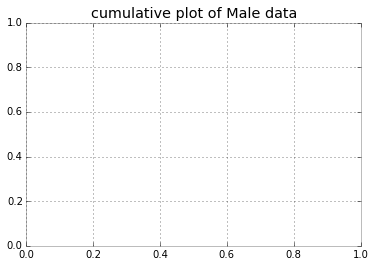

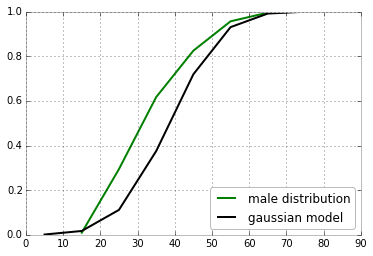

In [17]:
pl.title("cumulative plot of Male data")

#pl.hist(df.age, bins=bins)
pl.figure()
# i use nupy.vectorize to get the model value at all bin centers 
#one by one in a c-style for loop (not very pythonic or efficient, but easy to read)

pl.plot(bin_centers, cs1 / cs1.max(), 'g', label="male distribution")
pl.plot(bin_centers, model(bins[:-1], m ,s).cumsum()/model(bins[:-1], m, s).cumsum().max(),
            'k', label = "gaussian model")
pl.legend(loc = 4)
pl.xlabel="age"

#RUN THE TESTS NOW TO COMPARE TO normal DISTRIBUTION

In [19]:

A, crit, sig = scipy.stats.anderson(df.age[~np.isnan(df.age)], dist='norm')
#and run a test of anderson vs a normally distributed synthetic distribution : 
#i know this should show that the distributions are the same so it hels me make
#sure that I use the test right!
print '''AD for all year age vs normal: {0:.2f}, 
critical values: {1:s}, significance threshold: {2:s}'''.format(A, crit, sig)
A, crit, sig = scipy.stats.anderson(np.random.randn(1000), dist='norm')
print '''AD for NORMAL vs normal (expect a good match): {0:.2f}, 
critical values: {1:s}, significance threshold: {2:s}'''.format(A, crit, sig)
#and run a test of anderson of a gaussian vs a cauchy distributed synthetic distribution : 
#to see what a bad match looks like in the anderson test
A, crit, sig = scipy.stats.anderson(np.random.chisquare(1000,10000), dist='norm')
print '''AD for chi square vs normal (expect a bad match): {0:.2f}, 
critical values: {1:s}, significance threshold: {2:s}'''.format(A, crit, sig)



AD for male age vs normal: 26764.44, 
critical values: [ 0.576  0.656  0.787  0.918  1.092], significance threshold: [ 15.   10.    5.    2.5   1. ]
AD for NORMAL vs normal (expect a good match): 0.30, 
critical values: [ 0.574  0.653  0.784  0.914  1.088], significance threshold: [ 15.   10.    5.    2.5   1. ]
AD for chi square vs normal (expect a bad match): 1.86, 
critical values: [ 0.576  0.656  0.787  0.918  1.092], significance threshold: [ 15.   10.    5.    2.5   1. ]


FROM THE SCIPY MANUAL: 
    If A2 is larger than these critical values then for the corresponding significance level, the null hypothesis that the data come from the chosen distribution can be rejected.
    
    this is consistent which what i read the test output: 
    
##large values of the statistics means the year-round bikers age distribution is unlikely to come from the proposed (normal) distribution and my AD value is enormous: i can reject the normal distribution as a parent distribution for my data at >0.05 statistical significance (>0.01 as well)
    
    
    

In [25]:
ks = scipy.stats.kstest(df.age[~np.isnan(df.age)],'norm', args = (m,s))
print '''KS for all year age vs normal: {0:.2f}, pvalue:{1:.2f}'''.format(ks[0], ks[1]) 
ks = scipy.stats.kstest(np.random.randn(1000), 'norm')
print '''KS for normal vs normal: {0:.2f}, pvalue:{1:.2f}'''.format(ks[0], ks[1]) 
ks = scipy.stats.kstest(np.random.poisson(2,10000), 'norm', args = (2, np.sqrt(2)))
print '''KS for poisson vs normal: {0:.2f}, pvalue:{1:.2f}'''.format(ks[0], ks[1]) 


KS for all year age vs normal: 0.10, pvalue:0.00
KS for normal vs normal: 0.03, pvalue:0.29
KS for poisson vs normal: 0.17, pvalue:0.00


##similarly large values of the KS statistics means the year-round bikers age distribution is unlikely to come from the proposed (normal) distribution and my AD value is enormous: i can reject the normal distribution as a parent distribution for my data p-value = 0! (but always beware of the KS p-values...)
    
    

In [27]:
A, crit, sig = scipy.stats.anderson(dfsummer.age[~np.isnan(dfsummer.age)], dist='norm')
ks = scipy.stats.kstest(dfsummer.age[~np.isnan(dfsummer.age)],'norm', args = (m,s))
print '''AD for summer age vs normal: {0:.2f}, 
critical values: {1:s}, significance threshold: {2:s}'''.format(A, crit, sig)
print '''KS for summer age vs normal: {0:.2f}, 
pvalue {1:.2f}'''.format(ks[0], ks[1])

AD for summer age vs normal: 41623.79, 
critical values: [ 0.576  0.656  0.787  0.918  1.092], significance threshold: [ 15.   10.    5.    2.5   1. ]
KS for summer age vs normal: 0.12, 
pvalue 0.00


##since the distribution look nearly identical i already knew this, 
#the tests return a high confidence that the distribution is not gaussian for summer riders age as well

#trying to see if poisson is a better fit

In [76]:
#testing various poisson distributions
for i in range(1, 100, 5):
    ks = scipy.stats.kstest(dfsummer.age[~np.isnan(dfsummer.age)],'poisson', args = (i,))
    print i, ks

1 KstestResult(statistic=0.99999999999999889, pvalue=0.0)
6 KstestResult(statistic=0.99982512256458655, pvalue=0.0)
11 KstestResult(statistic=0.98991642506831568, pvalue=0.0)
16 KstestResult(statistic=0.93953285544001686, pvalue=0.0)
21 KstestResult(statistic=0.78112613697089728, pvalue=0.0)
26 KstestResult(statistic=0.5574957103111865, pvalue=0.0)
31 KstestResult(statistic=0.35584139275410231, pvalue=0.0)
36 KstestResult(statistic=0.22585912029458366, pvalue=0.0)
41 KstestResult(statistic=0.30652256873738393, pvalue=0.0)
46 KstestResult(statistic=0.44972212528034639, pvalue=0.0)
51 KstestResult(statistic=0.56184588853930284, pvalue=0.0)
56 KstestResult(statistic=0.66103930400530708, pvalue=0.0)
61 KstestResult(statistic=0.74653847577000976, pvalue=0.0)
66 KstestResult(statistic=0.82198338610607358, pvalue=0.0)
71 KstestResult(statistic=0.88027661794410672, pvalue=0.0)
76 KstestResult(statistic=0.92439463791100351, pvalue=0.0)
81 KstestResult(statistic=0.95618815483183861, pvalue=0.0)


In [78]:
#narrowing down near the distribution that performed best from the previous loop
for i in range(32, 41, 1):
    ks = scipy.stats.kstest(dfsummer.age[~np.isnan(dfsummer.age)],'poisson', args = (i,))
    print i, ks

32 KstestResult(statistic=0.32658737917177205, pvalue=0.0)
33 KstestResult(statistic=0.29948212175249156, pvalue=0.0)
34 KstestResult(statistic=0.27346110044039462, pvalue=0.0)
35 KstestResult(statistic=0.24989156524414202, pvalue=0.0)
36 KstestResult(statistic=0.22585912029458366, pvalue=0.0)
37 KstestResult(statistic=0.20167559552073056, pvalue=0.0)
38 KstestResult(statistic=0.19947512628033484, pvalue=0.0)
39 KstestResult(statistic=0.23877205728525105, pvalue=0.0)
40 KstestResult(statistic=0.27267740359309811, pvalue=0.0)


the best KS value I get for Poisson is a Poisson with pamaeter l=38 (which is close to the mean of the distribution.... what are the odds!) but KS thinks this is still a worse fit than gaussian

